# 題目二：長序列時間序列預測

## Informer 論文實作與 Vanilla Transformer 比較

本 Notebook 完成：

- Household Electric Power Consumption 資料下載與完整前處理
- 自行實作 Vanilla Transformer Baseline
- 依官方 Informer2020 架構改寫的現代 PyTorch Informer
- 96、336、672 三組 Input Length 的公平比較
- ProbSparse Self-Attention、Self-Attention Distilling、Generative Decoder 三項消融
- MAE、MSE、RMSE、每 Epoch／總訓練時間、Peak GPU Memory、推論時間、參數量

組員：請填入姓名與學號。

> 第一次請先使用 `QUICK_MODE=True` 跑通流程；正式作業務必改為 `False`。


## 0. 參考來源與實驗設定

- [Informer2020 官方程式庫](https://github.com/zhouhaoyi/Informer2020)
- [Kaggle Household Electric Power Consumption](https://www.kaggle.com/datasets/uciml/electric-power-consumption-data-set)
- [UCI 原始資料來源](https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption)

原始資料每分鐘取樣。為兼顧長序列與 RTX 3060 Laptop GPU 的可執行性，本實驗使用 15 分鐘平均重採樣：Input Length 96、336、672 約為 1 天、3.5 天、1 週；Prediction Horizon 96 為未來 1 天。


In [1]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "src").exists():
    candidate = PROJECT_DIR / "第二題_Informer"
    if not candidate.exists():
        raise FileNotFoundError("請從暑假作業資料夾或第二題_Informer 資料夾開啟本 Notebook。")
    os.chdir(candidate)
    PROJECT_DIR = candidate.resolve()

requirements = {
    "numpy": "numpy>=1.26",
    "pandas": "pandas>=2.0",
    "sklearn": "scikit-learn>=1.3",
    "matplotlib": "matplotlib>=3.8",
    "tqdm": "tqdm>=4.66",
    "torch": "torch>=2.2",
    "kagglehub": "kagglehub>=0.3",
}
missing = [package for module, package in requirements.items()
           if importlib.util.find_spec(module) is None]
if missing:
    print("Installing:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are available.")
print("Project directory:", PROJECT_DIR)


All required packages are available.
Project directory: /home/server-05/jay/Informer


## 1. 匯入程式與固定實驗條件

所有模型固定 seed、epochs、batch size、optimizer、初始 learning rate 與 scheduler 規則、資料切分、sliding-window stride 與評估方式。不同 Input Length 會對齊相同的預測起點，確保兩模型使用同一批 test targets。

所有模型預設使用 `ReduceLROnPlateau`：validation standardized MSE 連續 3 個 epoch 未達相對改善門檻 `1e-4` 時，learning rate 乘以 `0.5`，最低為 `1e-6`。調整後的值從下一個 epoch 使用；各模型下降時機可因 validation 表現不同而不同。設定 `USE_LR_SCHEDULER=False` 可停用。


In [2]:
import json
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display

from run_experiments import (
    DEFAULT_INPUT_LENGTHS,
    LABEL_LENGTH,
    PREDICTION_LENGTH,
    build_experiment_plan,
    save_summary_figures,
)
from src import ExperimentOptions, build_model, count_trainable_parameters
from src import prepare_power_data, run_experiment

QUICK_MODE = False
SEED = 42
EPOCHS = 10 if not QUICK_MODE else 1
BATCH_SIZE = 32 if not QUICK_MODE else 8
LEARNING_RATE = 1e-4
USE_LR_SCHEDULER = True
LR_SCHEDULER_FACTOR = 0.5
LR_SCHEDULER_PATIENCE = 2
LR_SCHEDULER_THRESHOLD = 1e-4
MIN_LEARNING_RATE = 1e-6
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("提醒：目前是 CPU 版 PyTorch；正式長序列實驗建議切換 CUDA kernel。")


Device: cuda
GPU: NVIDIA GeForce RTX 4090


/opt/anaconda3/envs/summer/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. 資料下載與前處理

處理順序：

1. 讀取 2,075,259 筆分鐘資料並依 timestamp 排序。
2. `?` 與空字串轉為缺失值。
3. 以 15 分鐘平均重採樣，時間內插後再補齊邊界。
4. 按時間 70%／15%／15% 切為 training／validation／test。
5. 只以 training 計算各數值特徵的 mean/std，避免資料洩漏。
6. 加入日內、星期與年內週期的 sin/cos time features。
7. Sliding window stride=4，即每小時建立一個樣本。


In [3]:
prepared = prepare_power_data(PROJECT_DIR / "data", frequency="15min")
print("Resampled rows:", len(prepared.values))
print("Date range:", prepared.timestamps[0], "→", prepared.timestamps[-1])
print("Numeric features:", prepared.columns)
print("Target mean/std from training:", prepared.target_mean, prepared.target_std)
print(
    "Split rows:",
    prepared.train_end,
    prepared.validation_end - prepared.train_end,
    len(prepared.values) - prepared.validation_end,
)


Resampled rows: 138352
Date range: 2006-12-16 17:15:00 → 2010-11-26 21:00:00
Numeric features: ('Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3')
Target mean/std from training: 1.0851433277130127 1.020828127861023
Split rows: 96846 20753 20753


## 3. 模型與實驗矩陣

Vanilla Transformer 包含 value/time/position embedding、Multi-head Attention、Encoder、Decoder 和 Prediction Head。Informer 依官方架構保留 ProbSparse query selection、encoder distilling 與一次輸出整段未來的 generative decoder。

消融都在最長序列 672 上進行，且每次只移除一個核心設計。


In [4]:
plan = build_experiment_plan(prepared.input_size, prepared.mark_size)
plan_frame = pd.DataFrame([asdict(config) for config in plan])
display(plan_frame[[
    "name", "model_type", "input_length", "prediction_length",
    "attention_type", "distil", "generative_decoder"
]])
print("Total experiments:", len(plan))


,name,model_type,input_length,prediction_length,attention_type,distil,generative_decoder
0,transformer_L96,transformer,96,96,full,False,True
1,informer_L96,informer,96,96,prob,True,True
2,transformer_L336,transformer,336,96,full,False,True
3,informer_L336,informer,336,96,prob,True,True
4,transformer_L672,transformer,672,96,full,False,True
5,informer_L672,informer,672,96,prob,True,True
6,ablate_probsparse_L672,informer,672,96,full,True,True
7,ablate_distilling_L672,informer,672,96,prob,False,True
8,ablate_generative_decoder_L672,informer,672,96,prob,True,False


Total experiments: 9


In [5]:
# 不訓練的架構尺寸檢查
for config in plan:
    model = build_model(config)
    print(f"{config.name:>34}: {count_trainable_parameters(model):,} parameters")
del model


                   transformer_L96: 119,809 parameters
                      informer_L96: 132,289 parameters
                  transformer_L336: 119,809 parameters
                     informer_L336: 132,289 parameters
                  transformer_L672: 119,809 parameters
                     informer_L672: 132,289 parameters
            ablate_probsparse_L672: 132,289 parameters
            ablate_distilling_L672: 119,809 parameters
    ablate_generative_decoder_L672: 87,648 parameters


/home/server-05/jay/Informer/src/models.py:390: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


## 4. 訓練、驗證與 Test 評估

正式模式共 9 組：6 組長序列主比較 + 3 組額外消融。每組完成指定 epochs 後，載入 validation MSE 最低的 checkpoint 再評估 test set；再次執行會重用版本與設定完全一致的 checkpoint。

> 更新程式後請重新啟動 kernel 並從頭執行。舊版 checkpoint 會自動重新訓練；本 Notebook 現有輸出仍為修改前的結果，須重新執行才會更新。

Peak GPU Memory 由 PyTorch CUDA allocator 記錄；推論前先 warm-up，再對同一 test loader 計時並同步 CUDA。

每個 epoch 的日誌及 `histories.json` 記錄 `learning_rate`（本輪使用值）與 `next_learning_rate`（調整後值）；`results.csv` 記錄初始與最終 learning rate。加入 scheduler 前的 checkpoint 會重新訓練；下方既有輸出尚未套用 scheduler，請同步遠端程式、重新啟動 kernel 並從頭執行。


In [6]:
options = ExperimentOptions(
    output_dir=OUTPUT_DIR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    use_lr_scheduler=USE_LR_SCHEDULER,
    lr_scheduler_factor=LR_SCHEDULER_FACTOR,
    lr_scheduler_patience=LR_SCHEDULER_PATIENCE,
    lr_scheduler_threshold=LR_SCHEDULER_THRESHOLD,
    min_learning_rate=MIN_LEARNING_RATE,
    weight_decay=1e-5,
    stride=4,
    seed=SEED,
    num_workers=0,
    alignment_input_length=max(DEFAULT_INPUT_LENGTHS),
    maximum_train_samples=256 if QUICK_MODE else None,
    maximum_validation_samples=64 if QUICK_MODE else None,
    maximum_test_samples=64 if QUICK_MODE else None,
    force_retrain=False,
)

results = []
histories = {}
prediction_samples = {}
for index, config in enumerate(plan, start=1):
    print(f"\n[{index}/{len(plan)}] {config.name}")
    result, history, sample = run_experiment(config, prepared, options)
    results.append(result)
    histories[config.name] = history
    prediction_samples[config.name] = sample

results_frame = pd.DataFrame(results)
results_frame.to_csv(OUTPUT_DIR / "results.csv", index=False, encoding="utf-8-sig")
with (OUTPUT_DIR / "histories.json").open("w", encoding="utf-8") as file:
    json.dump(histories, file, ensure_ascii=False, indent=2)

manifest = {
    "dataset": "Household Electric Power Consumption",
    "target": "Global_active_power",
    "frequency": prepared.frequency,
    "split": {"training": 0.70, "validation": 0.15, "test": 0.15},
    "standardization_fit": "training only",
    "input_lengths": list(DEFAULT_INPUT_LENGTHS),
    "label_length": LABEL_LENGTH,
    "prediction_length": PREDICTION_LENGTH,
    "quick_mode": QUICK_MODE,
    "options": {**asdict(options), "output_dir": str(OUTPUT_DIR.resolve())},
    "models": [asdict(config) for config in plan],
}
with (OUTPUT_DIR / "experiment_manifest.json").open("w", encoding="utf-8") as file:
    json.dump(manifest, file, ensure_ascii=False, indent=2, default=str)

display(results_frame)



[1/9] transformer_L96


/home/server-05/jay/Informer/src/models.py:390: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Ignoring incompatible checkpoint; retraining: /home/server-05/jay/Informer/outputs/checkpoints/transformer_L96.pt


  0%|          | 0/751 [00:00<?, ?it/s]/opt/anaconda3/envs/summer/lib/python3.13/site-packages/torch/autograd/graph.py:1072: UserWarning: Flash Attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:156.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


                   transformer_L96 | epoch 01/10 | train MSE=0.80042 | val MSE=0.63503 | lr=1.00e-04 | next lr=1.00e-04 | 4.7s


...

    ablate_generative_decoder_L672 | epoch 07/10 | train MSE=0.68337 | val MSE=0.64430 | lr=1.00e-04 | next lr=1.00e-04 | 7.4s


    ablate_generative_decoder_L672 | epoch 08/10 | train MSE=0.67660 | val MSE=0.63610 | lr=1.00e-04 | next lr=1.00e-04 | 5.9s


    ablate_generative_decoder_L672 | epoch 09/10 | train MSE=0.66960 | val MSE=0.63710 | lr=1.00e-04 | next lr=1.00e-04 | 4.6s


    ablate_generative_decoder_L672 | epoch 10/10 | train MSE=0.66418 | val MSE=0.63314 | lr=1.00e-04 | next lr=1.00e-04 | 5.2s
Using best validation checkpoint: epoch 10/10 | val MSE=0.63314


,name,model_type,input_length,prediction_length,attention_type,distil,generative_decoder,parameters,epochs,best_epoch,...,average_epoch_seconds,total_training_seconds,peak_gpu_memory_mb,device,mae,mse,rmse,inference_seconds,inference_ms_per_sample,test_samples
0,transformer_L96,transformer,96,96,full,False,True,119809,10,1,...,4.283630,42.836300,51.732910,cuda,0.502129,0.486757,0.697680,0.222158,0.044458,4997
1,informer_L96,informer,96,96,prob,True,True,132289,10,9,...,6.943113,69.431134,66.471191,cuda,0.483509,0.475536,0.689591,0.421599,0.084370,4997
2,transformer_L336,transformer,336,96,full,False,True,119809,10,3,...,6.283880,62.838799,91.800293,cuda,0.492797,0.497179,0.705109,0.226585,0.045344,4997
3,informer_L336,informer,336,96,prob,True,True,132289,10,6,...,8.447681,84.476808,138.434082,cuda,0.498351,0.486654,0.697606,0.418561,0.083762,4997
4,transformer_L672,transformer,672,96,full,False,True,119809,10,3,...,6.148485,61.484852,150.285156,cuda,0.489975,0.494337,0.703091,0.240499,0.048129,4997
5,informer_L672,informer,672,96,prob,True,True,132289,10,7,...,8.595087,85.950873,246.375488,cuda,0.502174,0.491858,0.701326,0.417599,0.083570,4997
6,ablate_probsparse_L672,informer,672,96,full,True,True,132289,10,2,...,9.848902,98.489017,811.468750,cuda,0.487772,0.476052,0.689965,0.623772,0.124829,4997
7,ablate_distilling_L672,informer,672,96,prob,False,True,119809,10,6,...,7.926992,79.269916,357.947266,cuda,0.499160,0.499020,0.706414,0.460257,0.092107,4997
8,ablate_generative_decoder_L672,informer,672,96,prob,True,False,87648,10,10,...,6.170211,61.702111,189.113770,cuda,0.496129,0.471205,0.686444,0.332761,0.066592,4997


## 5. 長序列比較

下表直接回答 Input Length 增加後，Transformer 與 Informer 在預測誤差、訓練效率、GPU 記憶體與推論速度上的變化。


In [7]:
main_results = results_frame[
    results_frame["name"].str.match(r"^(transformer|informer)_L")
].sort_values(["input_length", "model_type"])
display(main_results[[
    "model_type", "input_length", "mae", "mse", "rmse",
    "best_epoch", "best_validation_mse_standardized",
    "initial_learning_rate", "final_learning_rate",
    "average_epoch_seconds", "total_training_seconds",
    "peak_gpu_memory_mb", "inference_ms_per_sample", "parameters"
]])


,model_type,input_length,mae,mse,rmse,best_epoch,best_validation_mse_standardized,initial_learning_rate,final_learning_rate,average_epoch_seconds,total_training_seconds,peak_gpu_memory_mb,inference_ms_per_sample,parameters
1,informer,96,0.483509,0.475536,0.689591,9,0.626604,0.0001,0.000100,6.943113,69.431134,66.471191,0.084370,132289
0,transformer,96,0.502129,0.486757,0.697680,1,0.635032,0.0001,0.000013,4.283630,42.836300,51.732910,0.044458,119809
3,informer,336,0.498351,0.486654,0.697606,6,0.642075,0.0001,0.000050,8.447681,84.476808,138.434082,0.083762,132289
2,transformer,336,0.492797,0.497179,0.705109,3,0.622251,0.0001,0.000025,6.283880,62.838799,91.800293,0.045344,119809
5,informer,672,0.502174,0.491858,0.701326,7,0.646741,0.0001,0.000050,8.595087,85.950873,246.375488,0.083570,132289
4,transformer,672,0.489975,0.494337,0.703091,3,0.614565,0.0001,0.000025,6.148485,61.484852,150.285156,0.048129,119809


## 6. Informer 三項核心消融

- No ProbSparse：encoder／decoder self-attention 改為 Full Attention。
- No Distilling：保留每層完整序列，不使用 Conv + MaxPool 壓縮。
- No Generative Decoder：移除 decoder，改用 encoder 最後狀態一次直接預測整段未來。

下方的相對變化以完整 Informer 為基準；正的 error delta 表示移除該設計後誤差增加。


In [8]:
longest = max(DEFAULT_INPUT_LENGTHS)
ablation_names = [
    f"informer_L{longest}",
    f"ablate_probsparse_L{longest}",
    f"ablate_distilling_L{longest}",
    f"ablate_generative_decoder_L{longest}",
]
ablation = results_frame.set_index("name").loc[ablation_names].copy()
baseline_row = ablation.loc[f"informer_L{longest}"]
for metric in ("mae", "mse", "rmse", "average_epoch_seconds", "inference_ms_per_sample"):
    ablation[f"{metric}_change_percent"] = 100 * (
        ablation[metric] / baseline_row[metric] - 1
    )
display(ablation)


,model_type,input_length,prediction_length,attention_type,distil,generative_decoder,parameters,epochs,best_epoch,best_validation_mse_standardized,...,mse,rmse,inference_seconds,inference_ms_per_sample,test_samples,mae_change_percent,mse_change_percent,rmse_change_percent,average_epoch_seconds_change_percent,inference_ms_per_sample_change_percent
name,,,,,,,,,,,,,,,,,,,,,
informer_L672,informer,672,96,prob,True,True,132289,10,7,0.646741,...,0.491858,0.701326,0.417599,0.083570,4997,0.000000,0.000000,0.000000,0.000000,0.000000
ablate_probsparse_L672,informer,672,96,full,True,True,132289,10,2,0.616499,...,0.476052,0.689965,0.623772,0.124829,4997,-2.867939,-3.213656,-1.619949,14.587570,49.370941
ablate_distilling_L672,informer,672,96,prob,False,True,119809,10,6,0.654964,...,0.499020,0.706414,0.460257,0.092107,4997,-0.600082,1.456065,0.725401,-7.772995,10.215085
ablate_generative_decoder_L672,informer,672,96,prob,True,False,87648,10,10,0.633137,...,0.471205,0.686444,0.332761,0.066592,4997,-1.203765,-4.199032,-2.122031,-28.212351,-20.315543


## 7. 自動產生報告圖

會輸出：所有 loss 曲線、每組實際值／預測值、長序列準確度、長序列效率與 Informer 消融比較圖。


long_sequence_accuracy.png


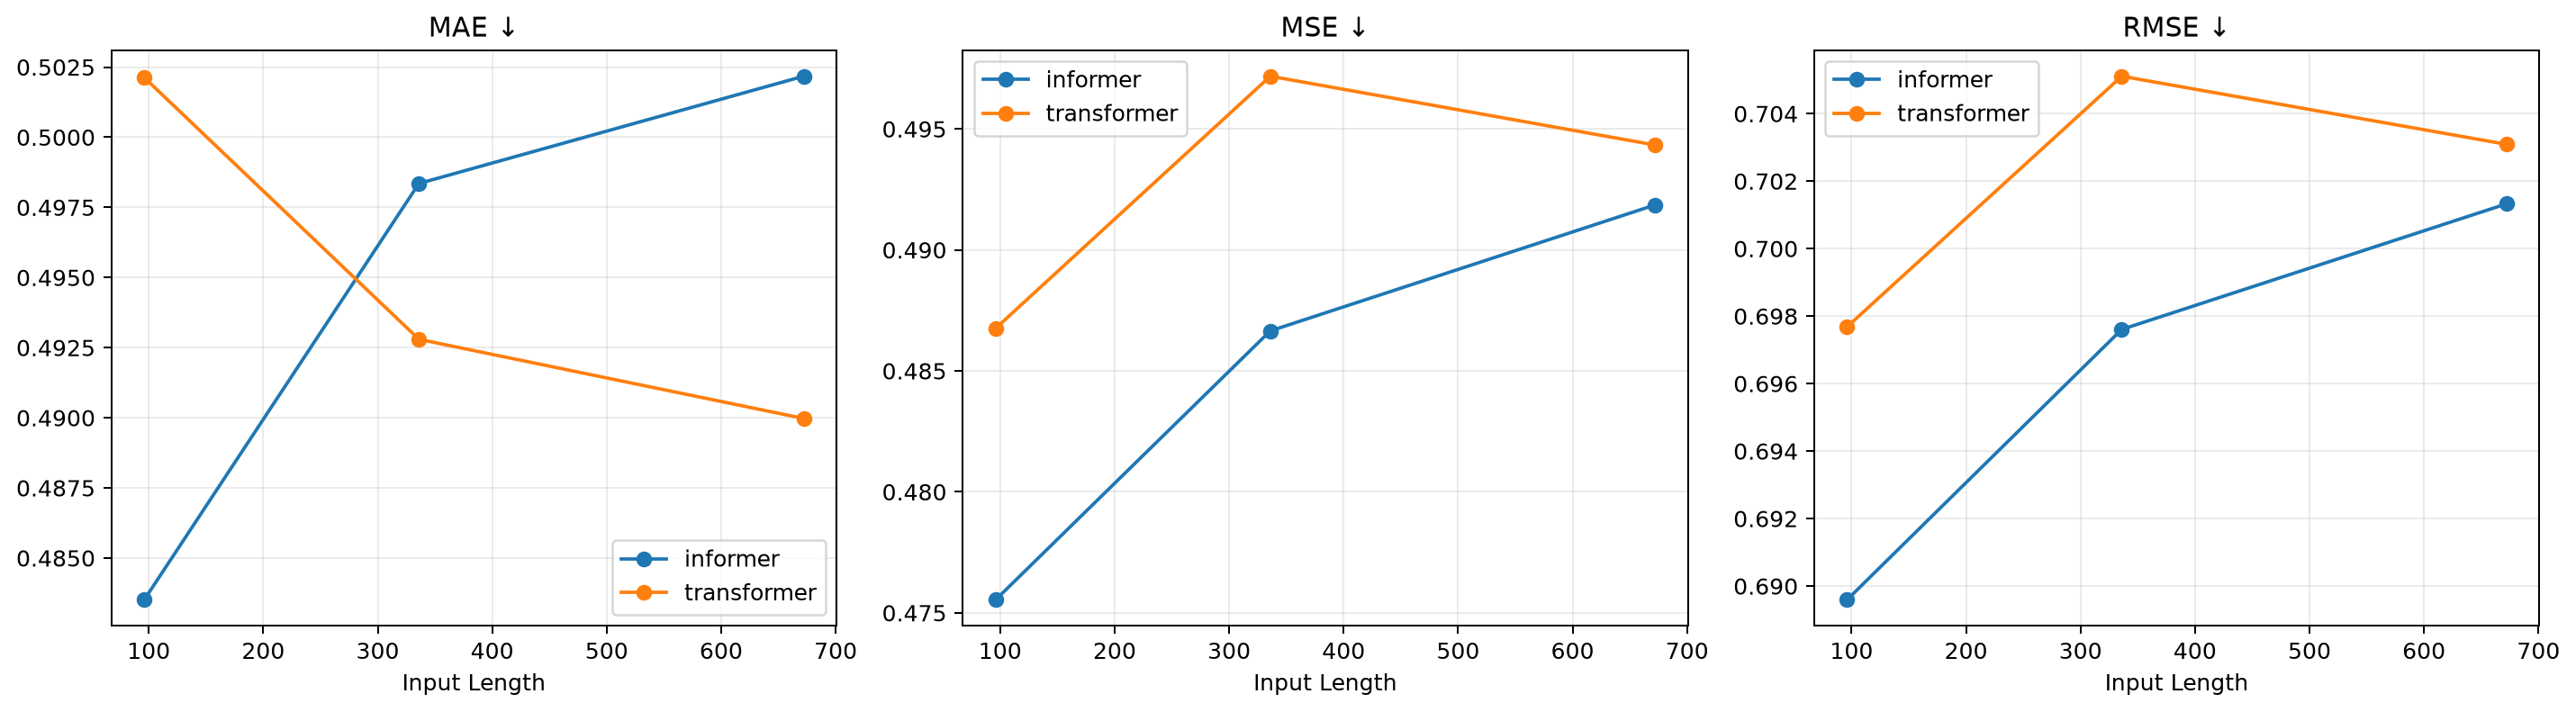

long_sequence_efficiency.png


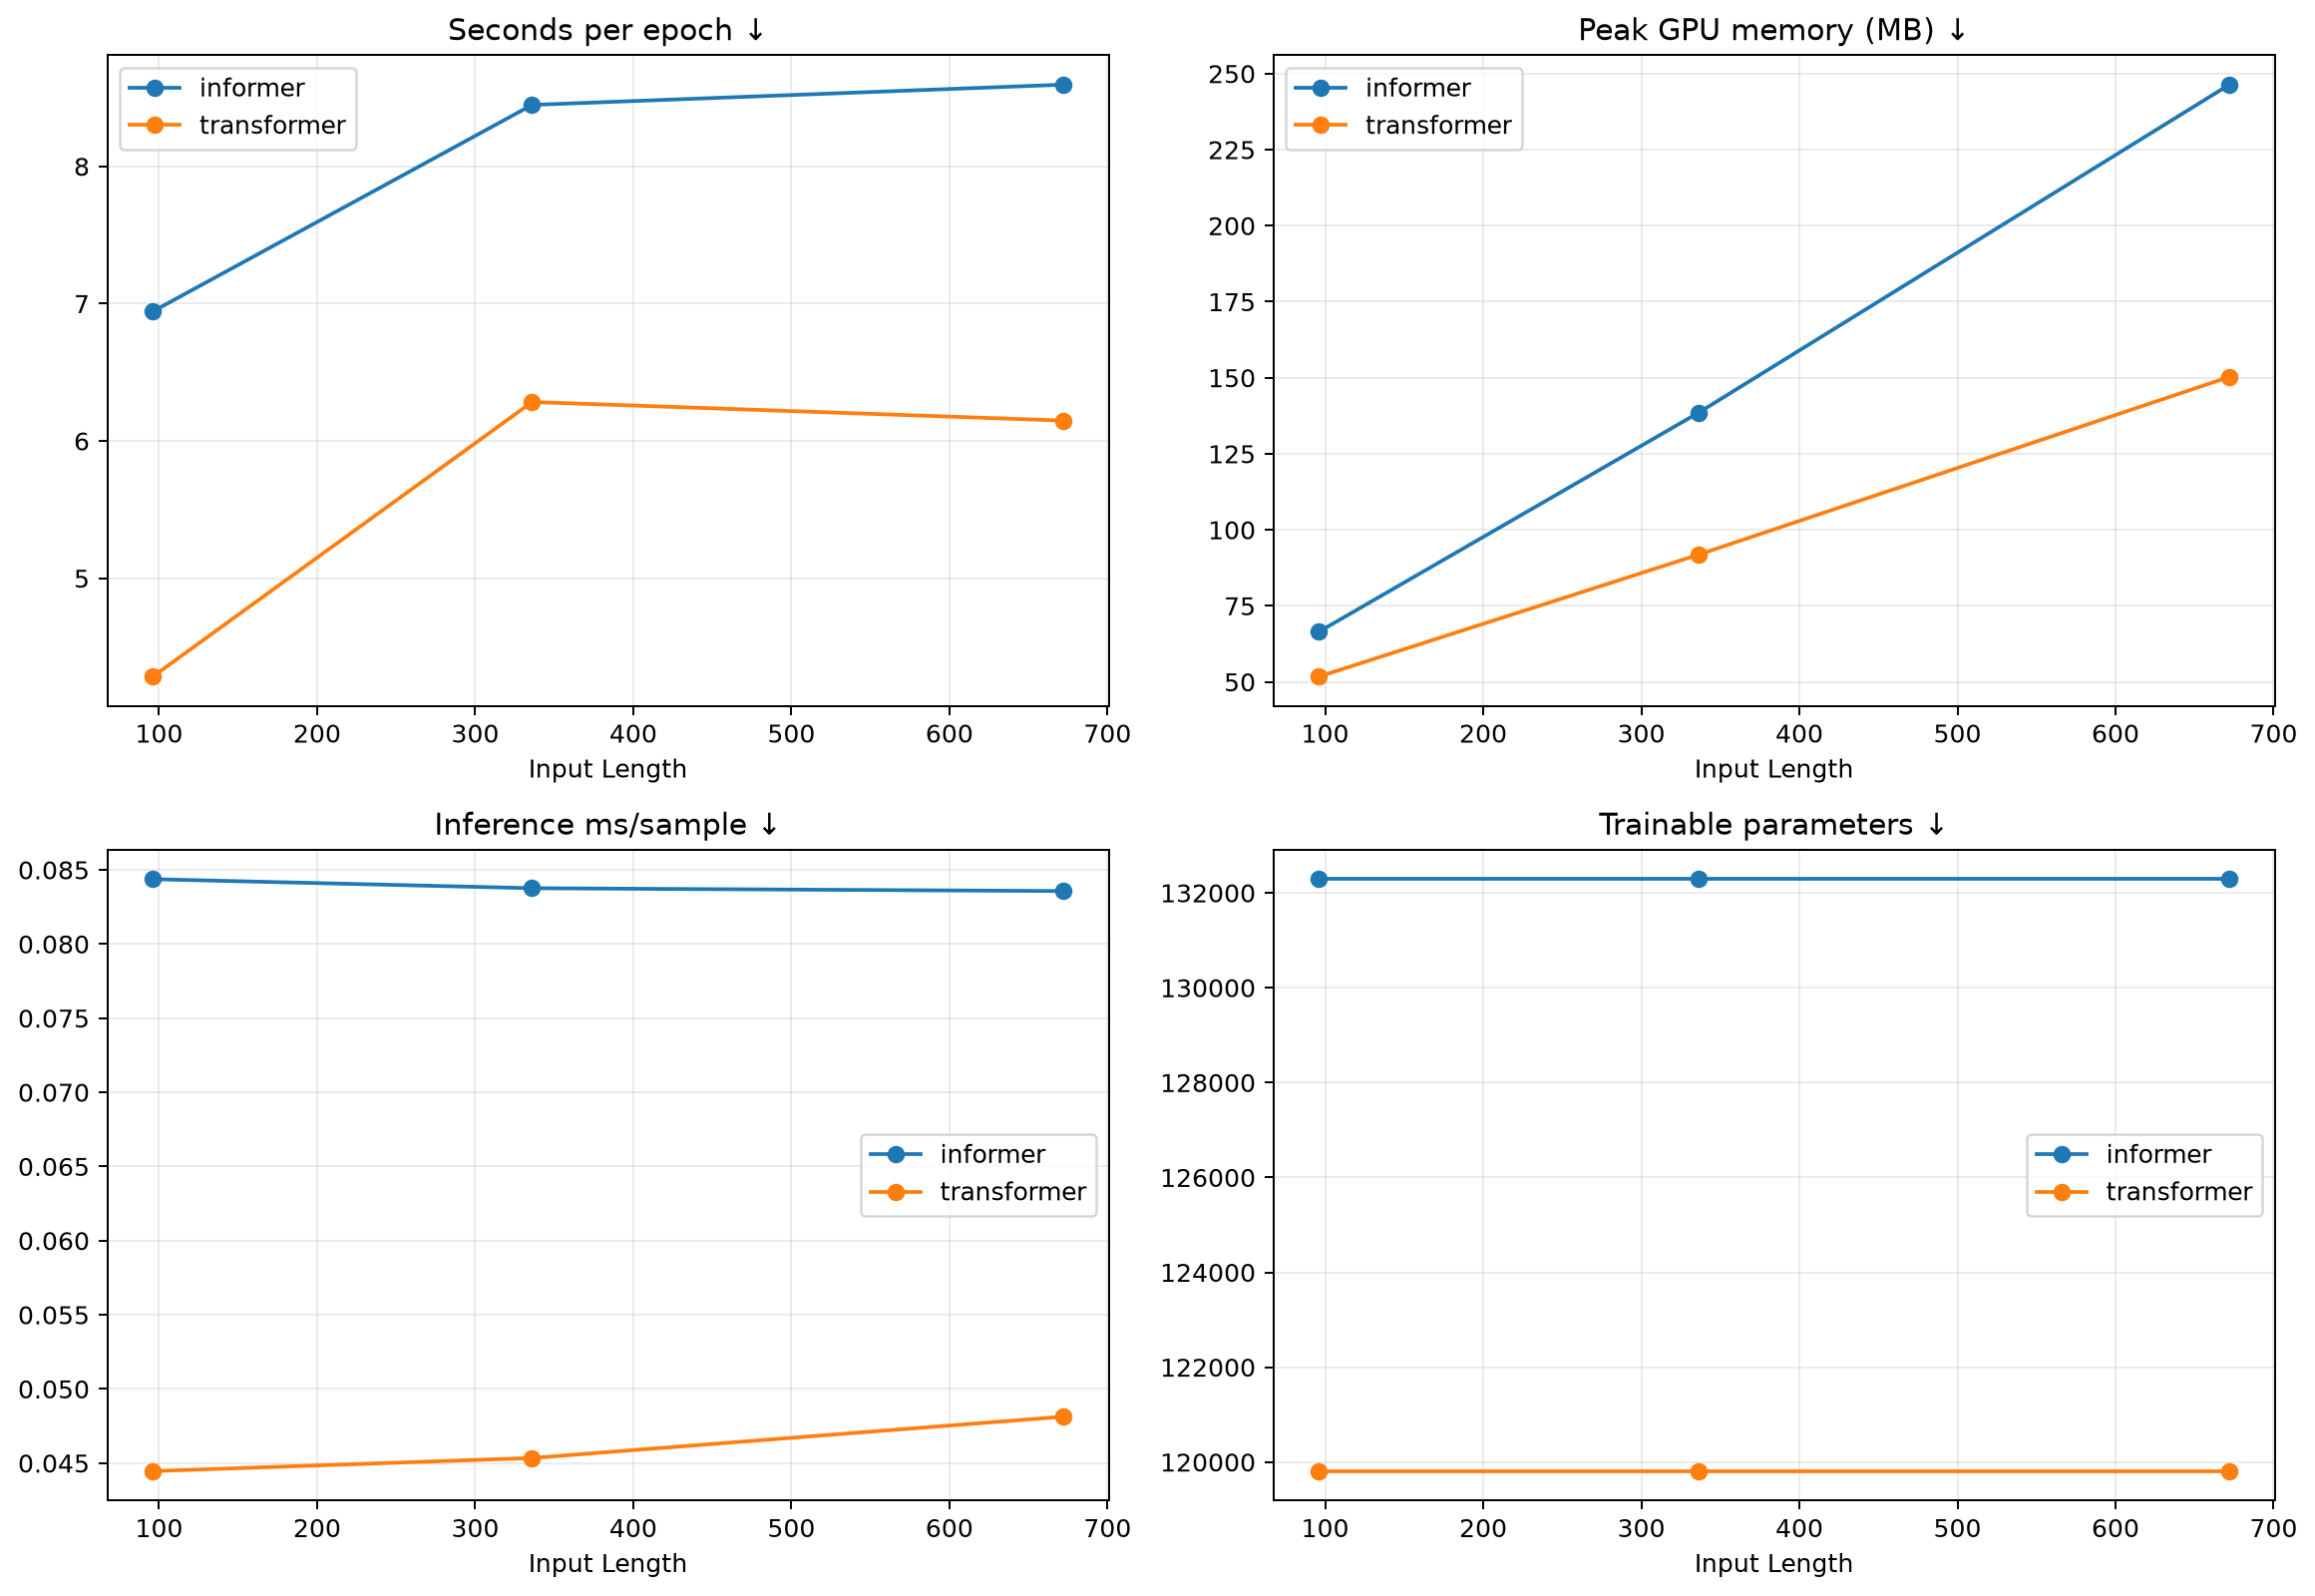

informer_ablation.png


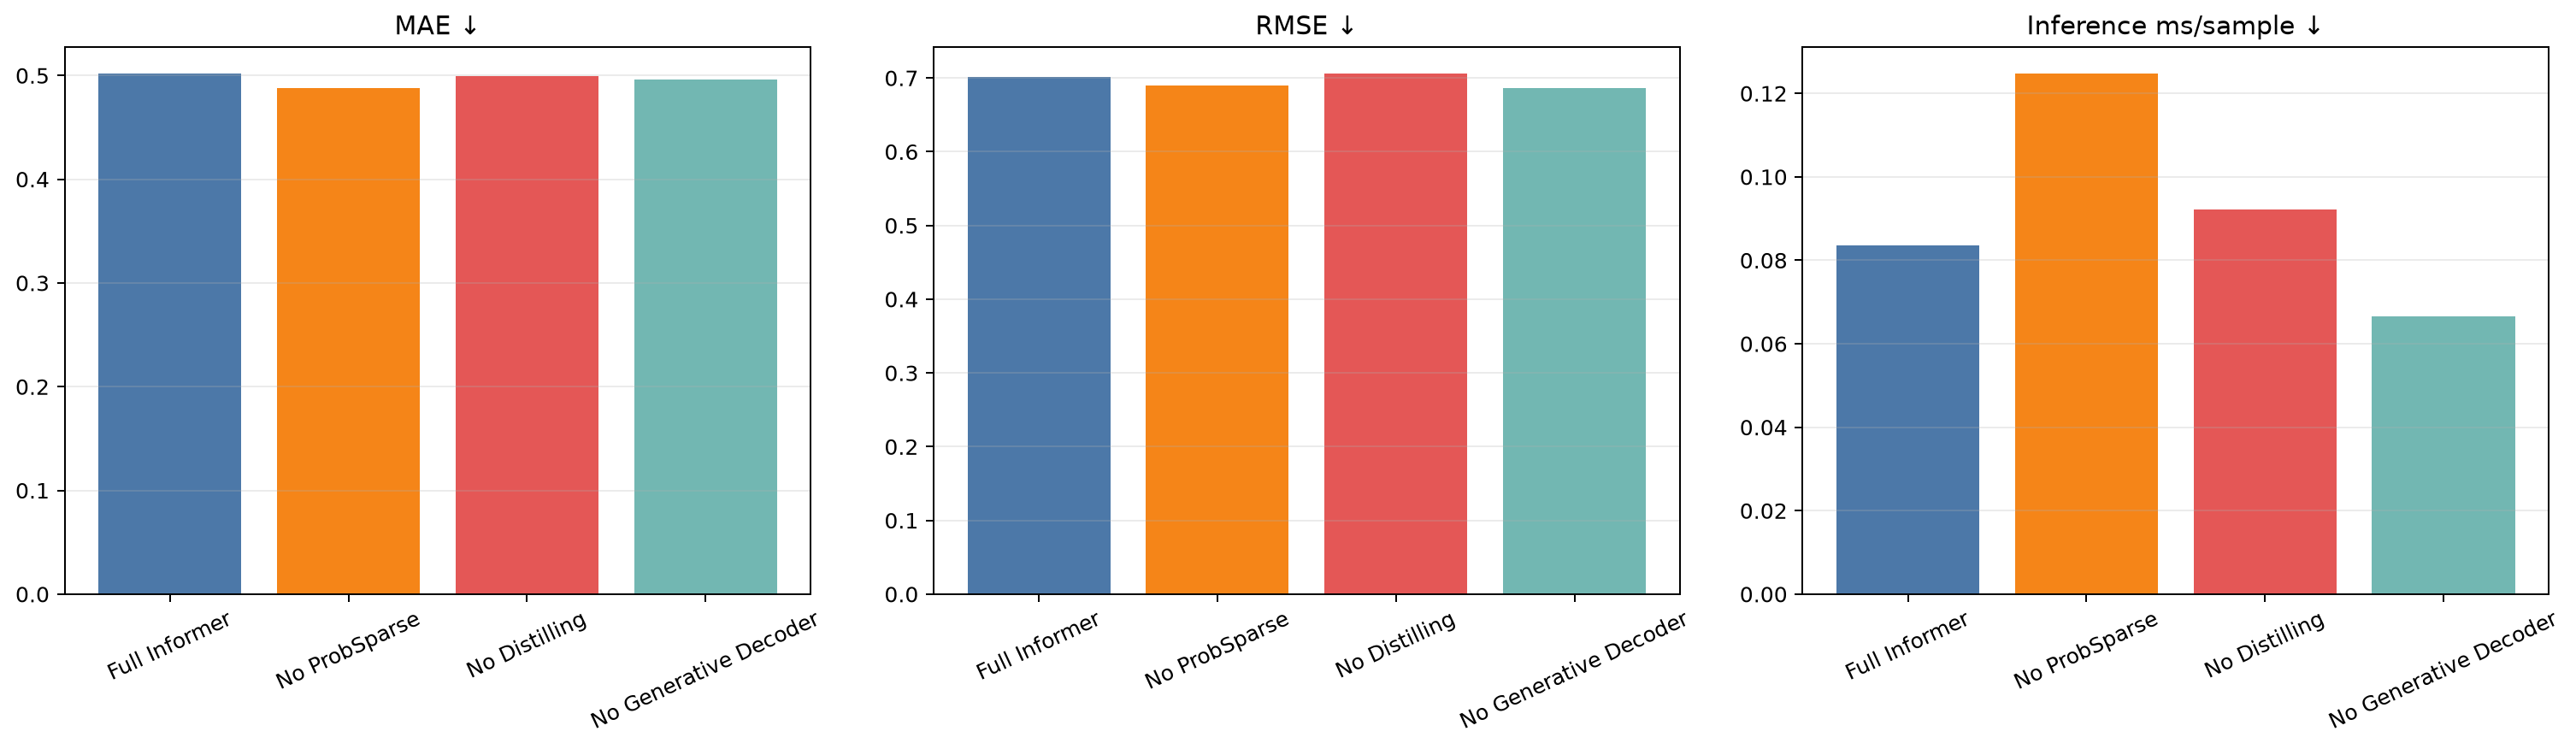

all_predictions.png


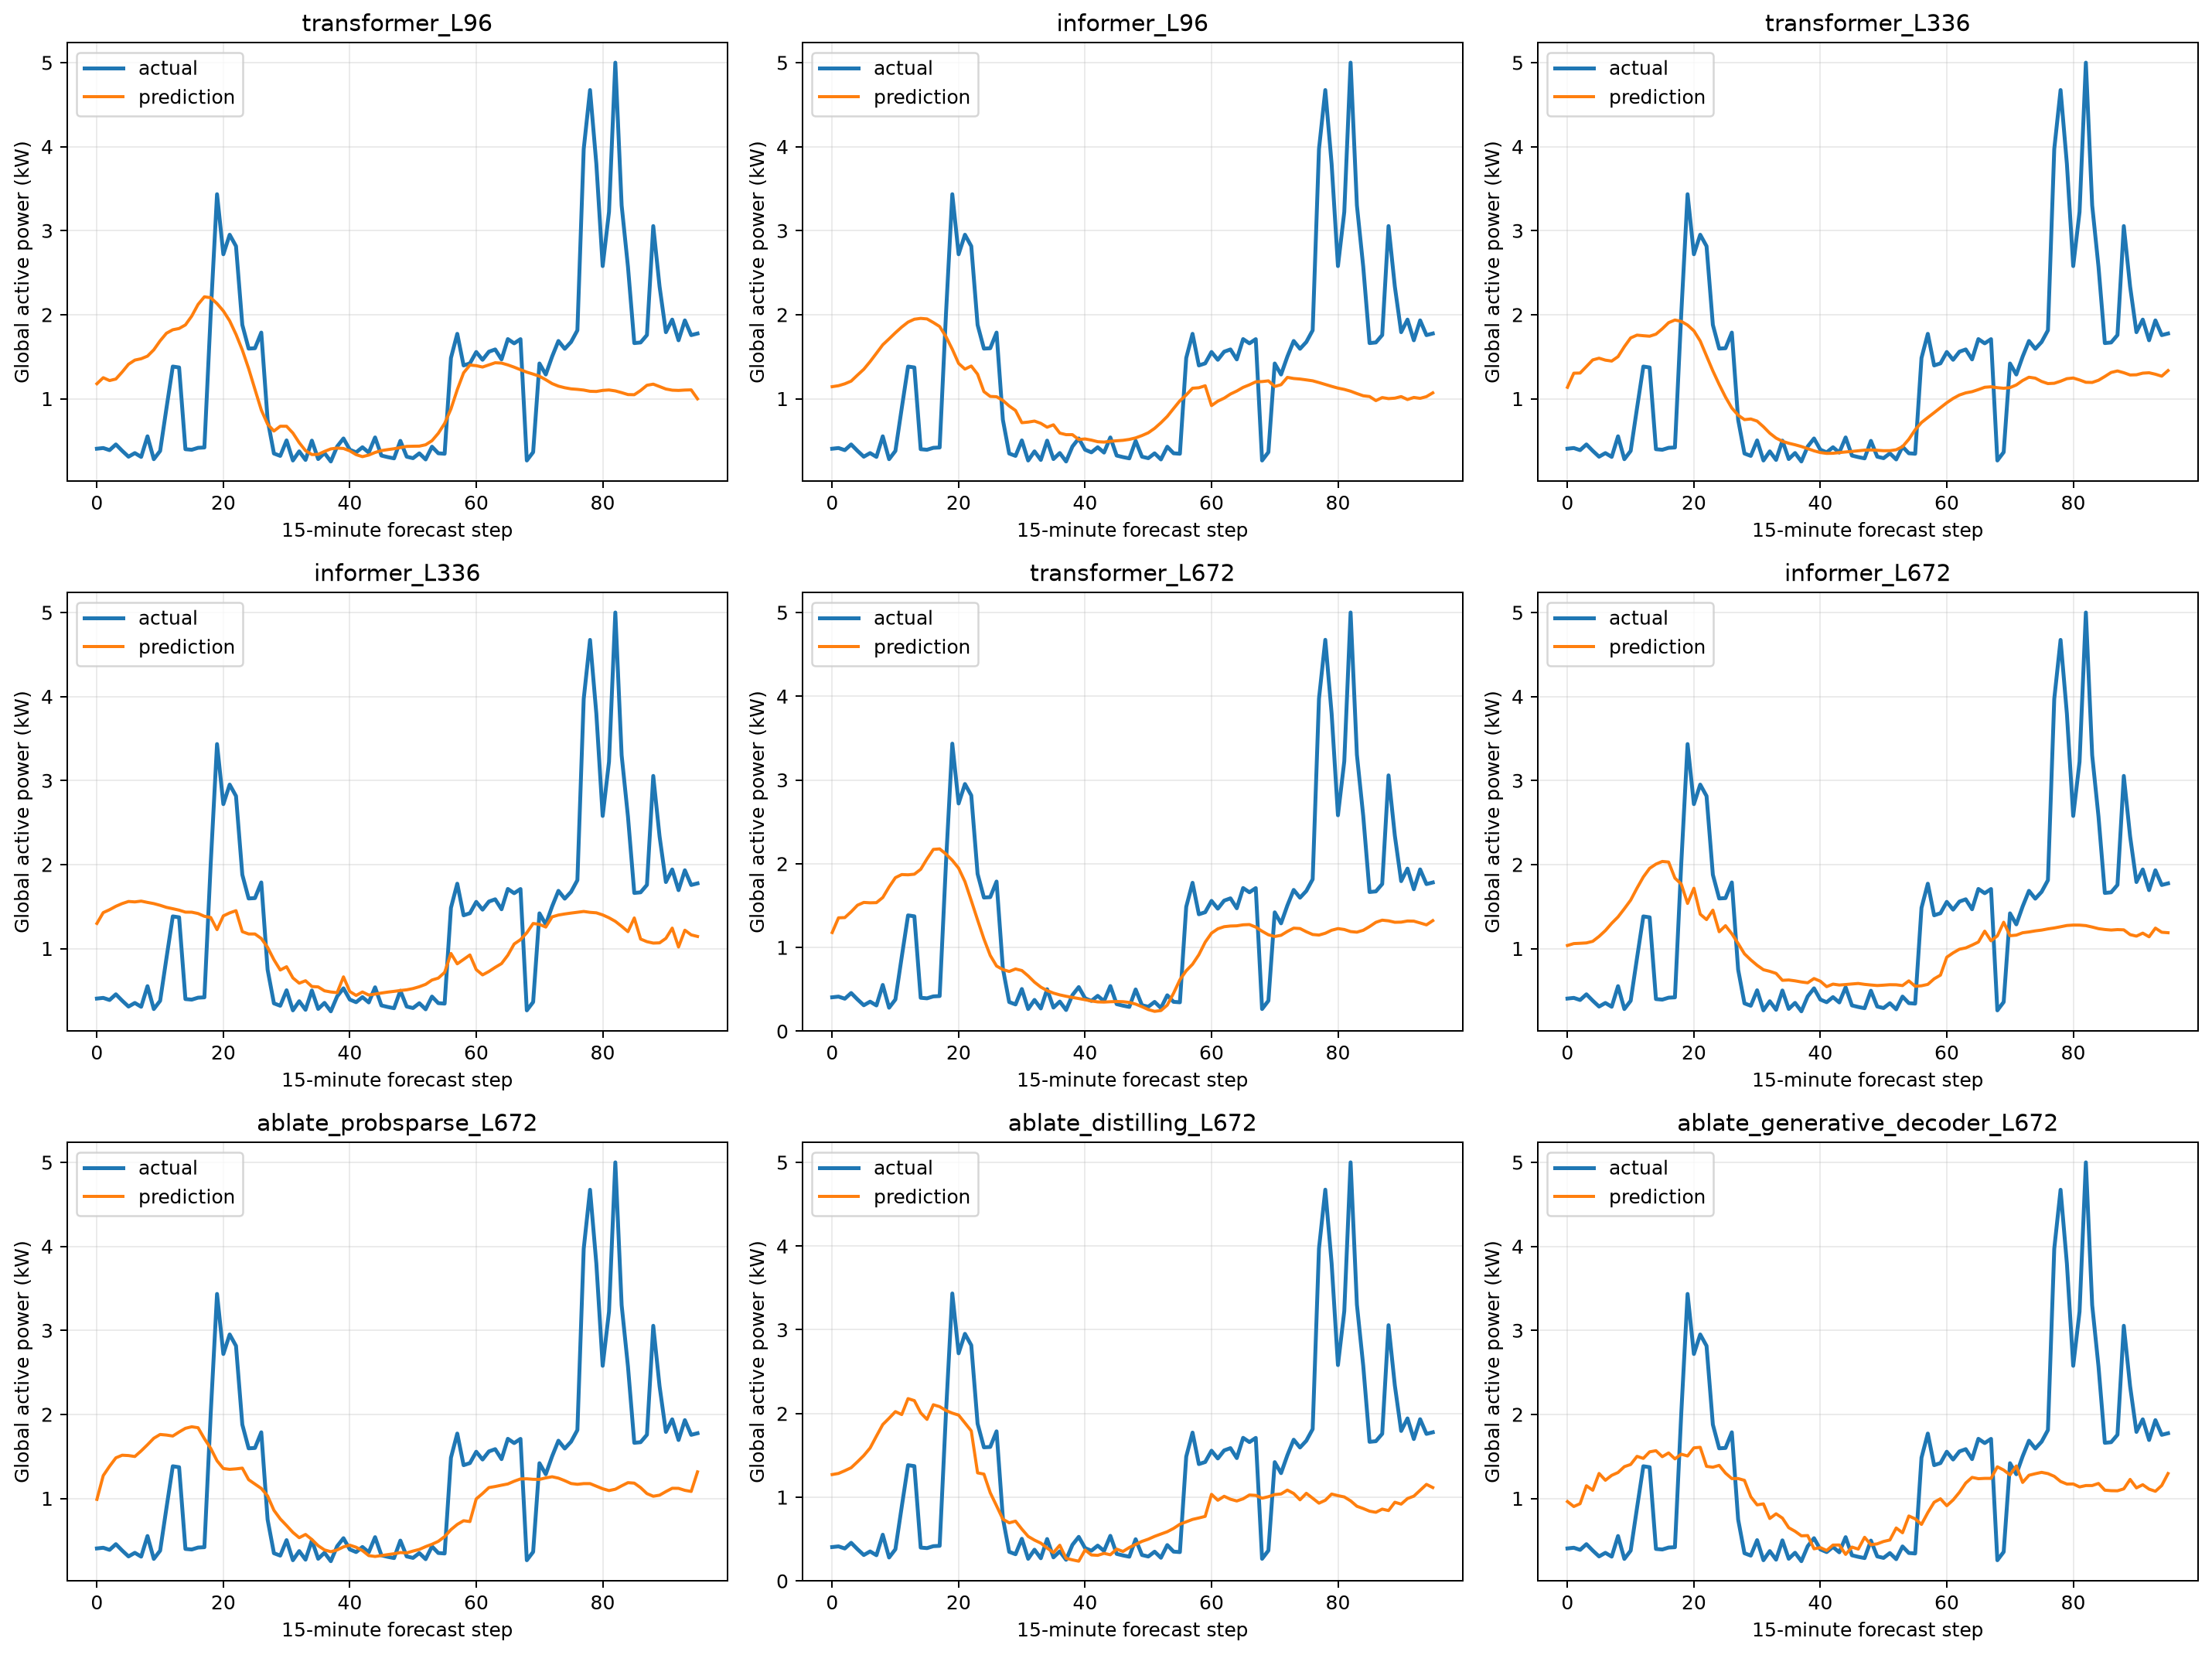

In [9]:
save_summary_figures(results_frame, histories, prediction_samples, OUTPUT_DIR)
for filename in (
    "long_sequence_accuracy.png",
    "long_sequence_efficiency.png",
    "informer_ablation.png",
    "all_predictions.png",
):
    print(filename)
    display(Image(filename=str(OUTPUT_DIR / "figures" / filename)))


## 8. 報告分析檢查表

- 清楚說明資料集、`Global_active_power` 目標、15 分鐘重採樣與未來一天預測的理由。
- 說明缺失值、排序、chronological split、training-only standardization 與 sliding window。
- 畫出兩模型架構，指出 Transformer 與 Informer attention／distilling／decoder 的差異。
- 逐一比較三組 Input Length 的 MAE、MSE、RMSE、時間、GPU memory 與推論速度。
- 判斷 Informer 是否隨序列變長開始展現優勢，並與論文的長序列主張比較。
- 三項消融逐一列出唯一變因、結果、影響大小與可能原因。
- 若結果不同於論文，從家庭用電週期、資料量、15 分鐘重採樣、模型容量與訓練 epochs 討論。
- 正式提交前確認 `QUICK_MODE=False` 且所有輸出已保存在 `outputs/`。
